# Machine Learning Final Project : Nutrient Regression
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [9]:
%reset -f

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import operator
import gc
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input

### Load Cleaned Dataset

In [11]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)

# Select all nutrient amount columns (exclude logs and package weight)
nutrient_cols = [col for col in food_data.columns if 'amount' in col and not col.endswith('_log') and not col == 'package_weight_amount']
print(f'Nutrient columns: {nutrient_cols}')

# Prepare input features (exclude nutrient columns)
exclude_cols = set(nutrient_cols)
feature_cols = [col for col in food_data.columns if col not in exclude_cols]

Nutrient columns: ['Acetic acid amount', 'Alanine amount', 'Alcohol, ethyl amount', 'Arginine amount', 'Ash amount', 'Aspartic acid amount', 'Beta-glucans amount', 'Biotin amount', 'Caffeine amount', 'Calcium, Ca amount', 'Carbohydrate, by difference amount', 'Carbohydrate, other amount', 'Carotene, beta amount', 'Chlorine, Cl amount', 'Cholesterol amount', 'Choline, from phosphotidyl choline amount', 'Choline, total amount', 'Chromium, Cr amount', 'Copper, Cu amount', 'Cysteine amount', 'Cystine amount', 'Energy amount', 'Epigallocatechin-3-gallate amount', 'Fatty acids, total monounsaturated amount', 'Fatty acids, total polyunsaturated amount', 'Fatty acids, total saturated amount', 'Fatty acids, total trans amount', 'Fiber, insoluble amount', 'Fiber, soluble amount', 'Fiber, total dietary amount', 'Fluoride, F amount', 'Folate, DFE amount', 'Folate, food amount', 'Folate, total amount', 'Folic acid amount', 'Fructose amount', 'Glucose amount', 'Glutamic acid amount', 'Glutamine amou

## Step 1: Train/Test Split

In [12]:
# Batch generator for memory-efficient training
def batch_generator(data, feature_cols, nutrient_cols, window_size=3, batch_size=128):
    num_rows = len(data)
    while True:
        for start in range(window_size, num_rows, batch_size):
            end = min(start + batch_size, num_rows)
            X_batch = []
            y_batch = []
            for i in range(start, end):
                X_window = data.iloc[i-window_size:i][feature_cols].values
                y_row = data.iloc[i][nutrient_cols].values
                X_batch.append(X_window)
                y_batch.append(y_row)
            yield np.array(X_batch), np.array(y_batch)

In [13]:
# Set window size and batch size
window_size = 3
batch_size = 128

# Calculate split index for train/test
num_rows = len(food_data)
split_idx = int((num_rows - window_size) * 0.8)
print(f'[Split] Total rows: {num_rows}, Train rows: {split_idx + window_size}, Test rows: {num_rows - split_idx}')

# Define train and test generators
train_gen = batch_generator(
    food_data.iloc[:split_idx + window_size],
    feature_cols,
    nutrient_cols,
    window_size=window_size,
    batch_size=batch_size
)
test_gen = batch_generator(
    food_data.iloc[split_idx:],
    feature_cols,
    nutrient_cols,
    window_size=window_size,
    batch_size=batch_size
)

# Calculate steps per epoch
train_steps = (split_idx) // batch_size
test_steps = (num_rows - window_size - split_idx) // batch_size
print(f'[Steps] Train steps per epoch: {train_steps}, Test steps: {test_steps}')

[Split] Total rows: 1977398, Train rows: 1581919, Test rows: 395482
[Steps] Train steps per epoch: 12358, Test steps: 3089


## Step 2: Build the Model

In [14]:
# Build the LSTM model for multi-output regression
print(f'[Model] Building LSTM model with input shape ({window_size}, {len(feature_cols)}) and output size {len(nutrient_cols)}')
model = Sequential()
model.add(Input(shape=(window_size, len(feature_cols))))
model.add(LSTM(units=128, return_sequences=True))
model.add(Dropout(0.2))

# Second LSTM layer with dropout regularization
model.add(LSTM(units=128))
model.add(Dropout(0.2))

# Final dense output layer for all nutrients
model.add(Dense(len(nutrient_cols)))

[Model] Building LSTM model with input shape (3, 1134) and output size 108


In [15]:
# Compile the model with Adam optimizer and MSE loss function
print('[Model] Compiling model...')
model.compile(optimizer='adam', loss='mean_squared_error')

[Model] Compiling model...


## Step 3: Train the Model

In [ ]:
# Fit the model using the batch generator
print(f'[Training] Starting model.fit for 10 epochs, batch size {batch_size}, train steps {train_steps}, validation steps {test_steps}')
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=3,
    validation_data=test_gen,
    validation_steps=test_steps
)

[Training] Starting model.fit for 10 epochs, batch size 128, train steps 12358, validation steps 3089
Epoch 1/10
Epoch 1/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2742s 222ms/step - loss: 2.4199e-05 - val_loss: 1.0786e-05
Epoch 2/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2742s 222ms/step - loss: 2.4199e-05 - val_loss: 1.0786e-05
Epoch 2/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2244s 182ms/step - loss: 7.1259e-06 - val_loss: 1.0781e-05
Epoch 3/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2244s 182ms/step - loss: 7.1259e-06 - val_loss: 1.0781e-05
Epoch 3/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1962s 159ms/step - loss: 7.1205e-06 - val_loss: 1.0780e-05
Epoch 4/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1962s 159ms/step - loss: 7.1205e-06 - val_loss: 1.0780e-05
Epoch 4/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1943s 157ms/step - loss: 7.1197e-06 - val_loss: 1.0777e-05
Epoch 5/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1943s 157ms/step - loss: 7.1197e-06 - val_loss: 1.0777e-05
Epoch 5/10
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1988s 161ms/step - 

In [17]:
# Collect predictions and true values from test generator for RMSE calculation
y_true = []
y_pred = []
for batch_num in range(test_steps):
    X_batch, y_batch = next(test_gen)
    preds = model.predict(X_batch)
    y_true.append(y_batch)
    y_pred.append(preds)
    gc.collect()
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

# Evaluate RMSE for each nutrient
rmses = [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(len(nutrient_cols))]
for col, rmse in zip(nutrient_cols, rmses):
    print(f'RMSE for {col}: {rmse:.4f}')

[Evaluation] Collecting predictions for 3089 test batches...
[Evaluation] Predicting batch 1/3089, batch size: 128
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
[Evaluation] Predicting batch 2/3089, batch size: 128
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[Evaluation] Predicting batch 2/3089, batch size: 128
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[Evaluation] Predicting batch 3/3089, batch size: 128
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step[Evaluation] Predicting batch 3/3089, batch size: 128
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[Evaluation] Predicting batch 4/3089, batch size: 128
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step[Evaluation] Predicting batch 4/3089, batch size: 128
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[Evaluation] Predicting batch 5/3089, batch size: 128
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[Evaluation] Predicting batch 5/3089, batch size: 128
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

## Step 4: Evaluate the Model

RMSE Summary:
Mean RMSE: 0.0021
Median RMSE: 0.0016
Min RMSE: 0.0000
Max RMSE: 0.0132


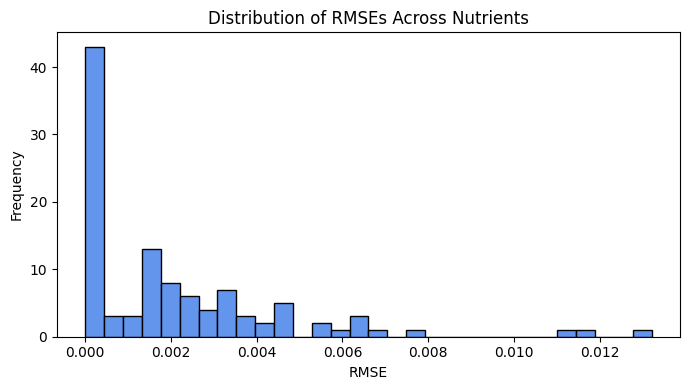

In [40]:
# Print summary statistics for RMSEs
print('RMSE Summary:')
print(f'Mean RMSE: {np.mean(rmses):.4f}')
print(f'Median RMSE: {np.median(rmses):.4f}')
print(f'Min RMSE: {np.min(rmses):.4f}')
print(f'Max RMSE: {np.max(rmses):.4f}')

# Plot RMSE distribution (histogram)
plt.figure(figsize=(7,4))
plt.hist(rmses, bins=30, color='cornflowerblue', edgecolor='black')
plt.xlabel('RMSE')
plt.ylabel('Frequency')
plt.title('Distribution of RMSEs Across Nutrients')
plt.tight_layout()
plt.show()

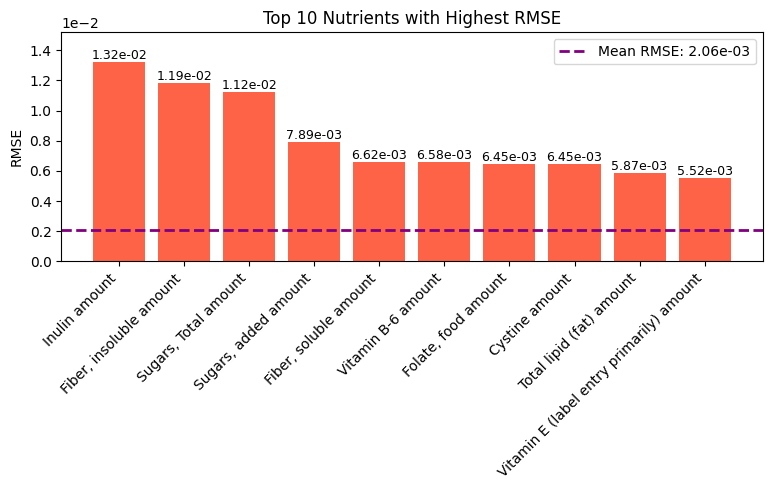

In [50]:
# Plot top 10 nutrients with highest RMSE
top_n = 10
nutrient_rmse_pairs = list(zip(nutrient_cols, rmses))
nutrient_rmse_pairs.sort(key=operator.itemgetter(1), reverse=True)
top_nutrients, top_rmses = zip(*nutrient_rmse_pairs[:top_n])
plt.figure(figsize=(8, 5))
bars = plt.bar(top_nutrients, top_rmses, color='tomato')
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title(f'Top {top_n} Nutrients with Highest RMSE')
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ylim(0, max(top_rmses) * 1.15)
# Add mean RMSE line
mean_rmse = np.mean(rmses)
plt.axhline(mean_rmse, color='purple', linestyle='--', linewidth=2, label=f'Mean RMSE: {mean_rmse:.2e}')
plt.legend()
for bar, value in zip(bars, top_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.2e}', ha='center', va='bottom', fontsize=9)
plt.show()

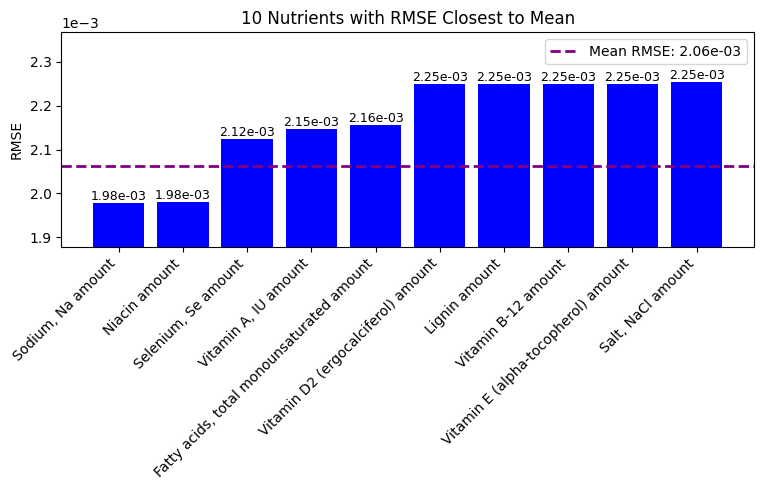

In [55]:
# Plot 10 nutrients with RMSEs closest to the mean RMSE
mean_rmse = np.mean(rmses)
nutrient_rmse_pairs = list(zip(nutrient_cols, rmses))
# Sort by absolute difference from mean RMSE
nutrient_rmse_pairs.sort(key=lambda x: abs(x[1] - mean_rmse))
closest_nutrients, closest_rmses = zip(*nutrient_rmse_pairs[:10])
# Sort selected nutrients by RMSE value
sorted_pairs = sorted(zip(closest_nutrients, closest_rmses), key=lambda x: x[1])
sorted_nutrients, sorted_rmses = zip(*sorted_pairs)
plt.figure(figsize=(8, 5))
bars = plt.bar(sorted_nutrients, sorted_rmses, color='blue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title('10 Nutrients with RMSE Closest to Mean')
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ylim(min(sorted_rmses) * 0.95, max(sorted_rmses) * 1.05)
plt.axhline(mean_rmse, color='purple', linestyle='--', linewidth=2, label=f'Mean RMSE: {mean_rmse:.2e}')
plt.legend()
for bar, value in zip(bars, sorted_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.2e}', ha='center', va='bottom', fontsize=9)
plt.show()

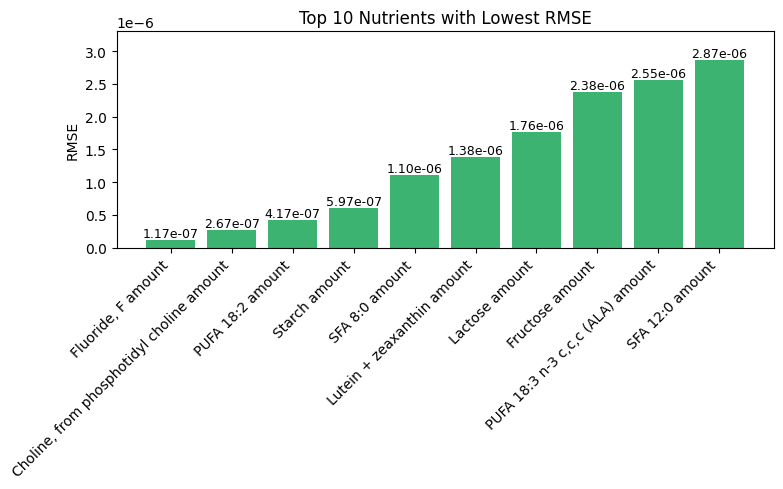

In [53]:
# Plot top 10 nutrients with lowest RMSE
bottom_n = 10
nutrient_rmse_pairs = list(zip(nutrient_cols, rmses))
nutrient_rmse_pairs.sort(key=operator.itemgetter(1))
bottom_nutrients, bottom_rmses = zip(*nutrient_rmse_pairs[:bottom_n])
plt.figure(figsize=(8, 5))
bars = plt.bar(bottom_nutrients, bottom_rmses, color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title(f'Top {bottom_n} Nutrients with Lowest RMSE')
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ylim(0, max(bottom_rmses) * 1.15)
for bar, value in zip(bars, bottom_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.2e}', ha='center', va='bottom', fontsize=9)
plt.show()